In [1]:
import pandas as pd

etf_raw = pd.read_excel('Spot ETFS for Major Global Indices.xlsx', sheet_name='Sheet2', header=None)


In [2]:
ticker_names = ['SPY US Equity', 'QQQ US Equity', 'EWJ US Equity', 'ASHR US Equity',
                'EWH US Equity', 'FEZ US Equity', 'INDA US Equity', 'CAC FP Equity', 'ISF LN Equity']
columns = ['Date'] + ticker_names


In [3]:
row_index = etf_raw[etf_raw.eq("SPY US Equity").any(axis=1)].index[0]
data = etf_raw.iloc[row_index + 1:, :len(columns)].copy()
data.columns = columns
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
df = data.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)

results = {}
for ticker in ticker_names:
    temp = df[['Date', ticker]].copy()
    temp = temp.rename(columns={ticker: 'Price'}).dropna()
    if len(temp) < 15:
        continue
    temp['SMA_10'] = temp['Price'].rolling(10).mean()
    temp['SMA_Signal'] = (temp['Price'] > temp['SMA_10']).astype(int)
    temp['Momentum'] = temp['Price'] - temp['Price'].shift(5)
    temp['Momentum_Signal'] = (temp['Momentum'] > 0).astype(int)
    temp['Reversal'] = temp['Price'].pct_change()
    temp['Reversal_Signal'] = (temp['Reversal'] < -0.03).astype(int)

    last = temp.dropna().iloc[-1]
    results[ticker] = {
        'SMA': 'Long' if last['SMA_Signal'] == 1 else 'Short',
        'Momentum': 'Long' if last['Momentum_Signal'] == 1 else 'Short',
        'Reversal': 'Long' if last['Reversal_Signal'] == 1 else 'No Trade'
    }

signals_df = pd.DataFrame(results).T.reset_index()
signals_df.columns = ['Ticker', 'SMA', 'Momentum', 'Reversal']
signals_df.to_csv('signals_summary.csv', index=False)

signals_df


<ipython-input-3-81a37698a890>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
<ipython-input-3-81a37698a890>:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp['Reversal'] = temp['Price'].pct_change()
<ipython-input-3-81a37698a890>:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp['Reversal'] = temp['Price'].pct_change()
<ipython-input-3-81a37698

,Ticker,SMA,Momentum,Reversal
0,SPY US Equity,Short,Short,No Trade
1,QQQ US Equity,Short,Short,No Trade
2,EWJ US Equity,Long,Short,No Trade
3,ASHR US Equity,Short,Short,No Trade
4,EWH US Equity,Short,Short,No Trade
5,FEZ US Equity,Long,Long,No Trade
6,INDA US Equity,Long,Long,No Trade
7,CAC FP Equity,Short,Short,No Trade
8,ISF LN Equity,Short,Short,No Trade


,Ticker,SMA,Momentum,Reversal
0,SPY US Equity,Short,Short,No Trade
1,QQQ US Equity,Short,Short,No Trade
3,ASHR US Equity,Short,Short,No Trade
4,EWH US Equity,Short,Short,No Trade
5,FEZ US Equity,Long,Long,No Trade
6,INDA US Equity,Long,Long,No Trade
7,CAC FP Equity,Short,Short,No Trade
8,ISF LN Equity,Short,Short,No Trade


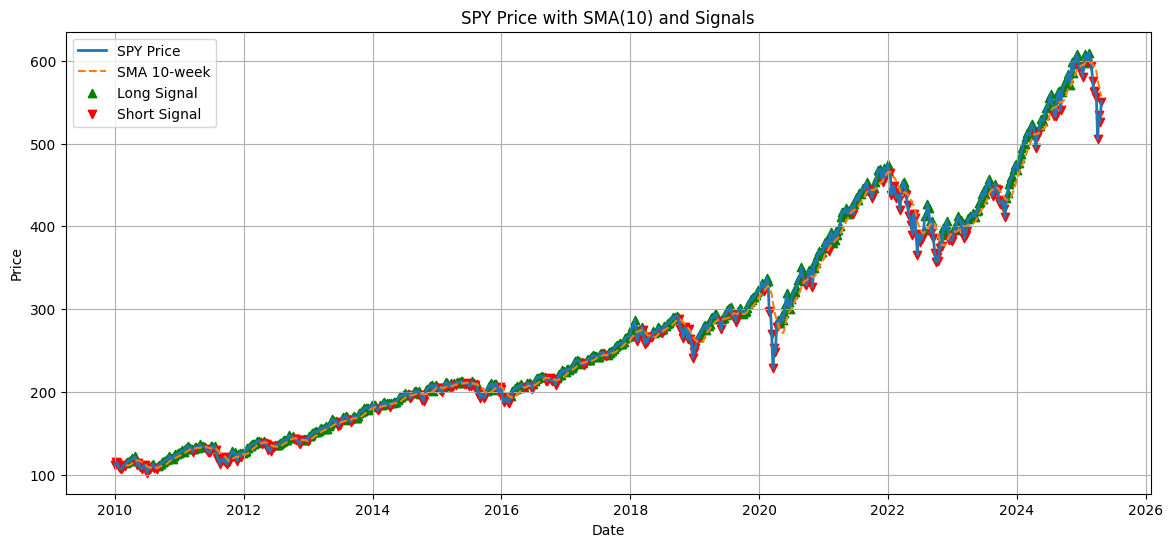

In [4]:
import matplotlib.pyplot as plt


spy = df[['Date', 'SPY US Equity']].dropna()
spy = spy.rename(columns={'SPY US Equity': 'Price'})
spy['SMA_10'] = spy['Price'].rolling(10).mean()
spy['Signal'] = (spy['Price'] > spy['SMA_10']).astype(int)


plt.figure(figsize=(14,6))
plt.plot(spy['Date'], spy['Price'], label='SPY Price', linewidth=2)
plt.plot(spy['Date'], spy['SMA_10'], label='SMA 10-week', linestyle='--')

longs = spy[spy['Signal'] == 1]
shorts = spy[spy['Signal'] == 0]
plt.scatter(longs['Date'], longs['Price'], marker='^', color='green', label='Long Signal')
plt.scatter(shorts['Date'], shorts['Price'], marker='v', color='red', label='Short Signal')

plt.title('SPY Price with SMA(10) and Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()
